# Véhicle counting system

**Objectif** : tester interactivement, sur une vidéo d'exemple, l'ensemble de la chaîne
avant de lancer `src/vehicle_counter.py` en conditions réelles :
- vérifier visuellement que le tracking (ByteTrack) garde des IDs stables
- vérifier que les lignes IN/OUT sont bien positionnées et que le sens compté est correct
- visualiser l'évolution des comptages dans le temps (utile pour repérer une anomalie :
  un pic anormal de comptage = souvent un ID switch du tracker, pas un vrai flux de véhicules)

Dépose une courte vidéo de test dans `data/sample_videos/` avant de lancer ce notebook.

Pas d'entraînement ici : le modèle YOLO pré-entraîné COCO connaît déjà nativement
`voiture`/`camion`/`moto`/`bus`/`velo` (voir README).

In [3]:
import sys
sys.path.append("../src")  # pour importer counter_core.py

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

from counter_core import LineCounter, VEHICLE_CLASSES, draw_line_with_arrow, draw_counts_table

VIDEO_PATH = "../data/sample_videos/Test Video.mp4"  # <- adapte au nom de ta vidéo de test
assert Path(VIDEO_PATH).exists(), f"Dépose une vidéo de test dans data/sample_videos/ (attendu: {VIDEO_PATH})"


## 1.Aperçu de la 1er frame - la positionnement de lignes

Dimensions : 1280x720


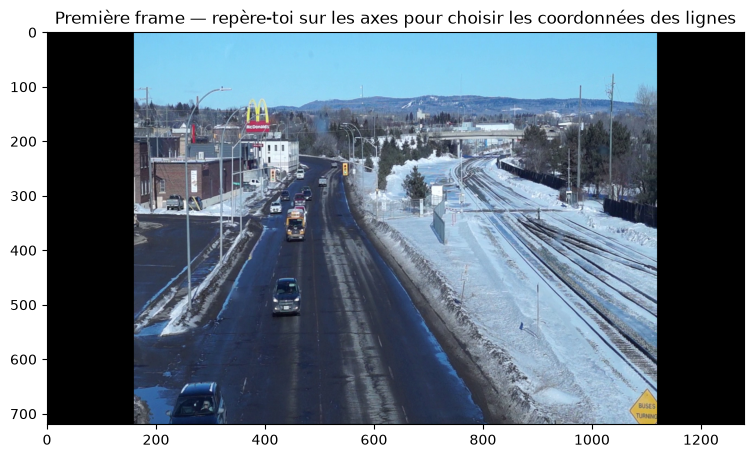

In [4]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()
h, w = first_frame.shape[:2]
print(f"Dimensions : {w}x{h}")

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title("Première frame — repère-toi sur les axes pour choisir les coordonnées des lignes")
plt.show()

## 2. Définition manuelle des lignes (coordonnées en pixels)

Ajuste ces valeurs en te basant sur l'image ci-dessus, puis vérifie l'aperçu
avec la flèche de sens avant de lancer le comptage complet.

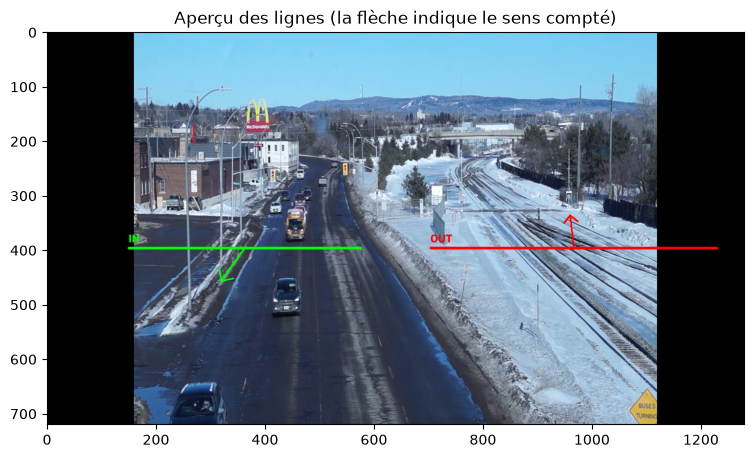

In [9]:
in_line = {"p1": (150, int(h*0.55)), "p2": (int(w*0.45), int(h*0.55)), "direction_point": (int(w*0.25), int(h*0.55)+60)}
out_line = {"p1": (int(w*0.55), int(h*0.55)), "p2": (w-50, int(h*0.55)), "direction_point": (int(w*0.75), int(h*0.55)-60)}

preview = first_frame.copy()
draw_line_with_arrow(preview, in_line, (0, 255, 0), "IN", cv2)
draw_line_with_arrow(preview, out_line, (0, 0, 255), "OUT", cv2)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title("Aperçu des lignes (la flèche indique le sens compté)")
plt.show()
